<a href="https://colab.research.google.com/github/AlejandraConB/analisis_netflix/blob/main/Curso_bigdata_netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
# Cargar el archivo en un DataFrame de pandas
df = pd.read_csv('netflix_titles.csv')

In [ ]:
# Mostrar las primeras filas del dataset para explorarlo
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Ver información general del dataset
df.info()

# Ver estadísticas básicas del dataset
df.describe()

# Ver los nombres de las columnas
df.columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Mostrar el tipo de dato de todas las columnas del DataFrame
print(df.dtypes)


show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


Problemas con la columna duration por el tipo de dato

In [ ]:
# Mostrar el tipo de dato de la columna 'duration'
print(df['duration'].dtype)


object


**Pregunta 1: ¿Cuál es el género más popular en Netflix?**

---



In [ ]:
# Contar cuántos títulos pertenecen a cada género
genre_counts = df['listed_in'].value_counts().head(10)
print(genre_counts)


listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


**Pregunta 2: ¿Qué país produce más contenido en Netflix?**

---



In [ ]:
# Contar el número de títulos por país
country_counts = df['country'].value_counts().head(10)
print(country_counts)


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


**Pregunta 3: ¿Cuáles son las cinco películas más largas en la plataforma?**

---



In [ ]:
# Filtrar solo las películas
df_movies = df[df['type'] == 'Movie']

# Filtrar las filas que contienen 'min' en la columna 'duration'
df_movies = df_movies[df_movies['duration'].str.contains('min', na=False)]

# Eliminar 'min' y convertir la columna a tipo float
df_movies['duration'] = df_movies['duration'].str.replace(' min', '').astype(float)

# Ordenar por duración (de mayor a menor)
longest_movies = df_movies.sort_values(by='duration', ascending=False).head(5)

# Mostrar las 5 películas más largas
print(longest_movies[['title', 'duration']])


                            title  duration
4253   Black Mirror: Bandersnatch     312.0
717   Headspace: Unwind Your Mind     273.0
2491       The School of Mischief     253.0
2487               No Longer kids     237.0
2484           Lock Your Girls In     233.0


**Pregunta 4: ¿Cómo ha variado la cantidad de lanzamientos de contenido por año?**

---



In [ ]:
# Contar la cantidad de títulos lanzados por año
release_year_counts = df['release_year'].value_counts().sort_index()
print(release_year_counts)


release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


**Pregunta 5: ¿Cuántos títulos tienen una duración mayor a 120 minutos?**

---



In [ ]:
# Filtrar solo las películas
df_movies = df[df['type'] == 'Movie']

# Filtrar las filas que contienen 'min' en la columna 'duration'
df_movies = df_movies[df_movies['duration'].str.contains('min', na=False)]

# Eliminar 'min' y convertir la duración a números (float)
df_movies['duration'] = df_movies['duration'].str.replace(' min', '').astype(float)

# Filtrar solo las películas con duración mayor a 120 minutos
long_movies = df_movies[df_movies['duration'] > 120]

# Mostrar las películas con duración mayor a 120 minutos
print(long_movies[['title', 'duration']])


                      title  duration
7                   Sankofa     125.0
12             Je Suis Karl     127.0
22          Avvai Shanmughi     161.0
24                    Jeans     166.0
26           Minsara Kanavu     147.0
...                     ...       ...
8772  Yamla Pagla Deewana 2     147.0
8773    Yanda Kartavya Aahe     151.0
8788           You Carry Me     157.0
8798               Zed Plus     131.0
8802                 Zodiac     158.0

[1142 rows x 2 columns]


**Visualización con gráficos**

---



**Gráfico 1: Distribución de géneros en Netflix**

<ipython-input-15-ecaebabebd0f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='coolwarm')
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_base.py:949: FutureWarning: When grouping 

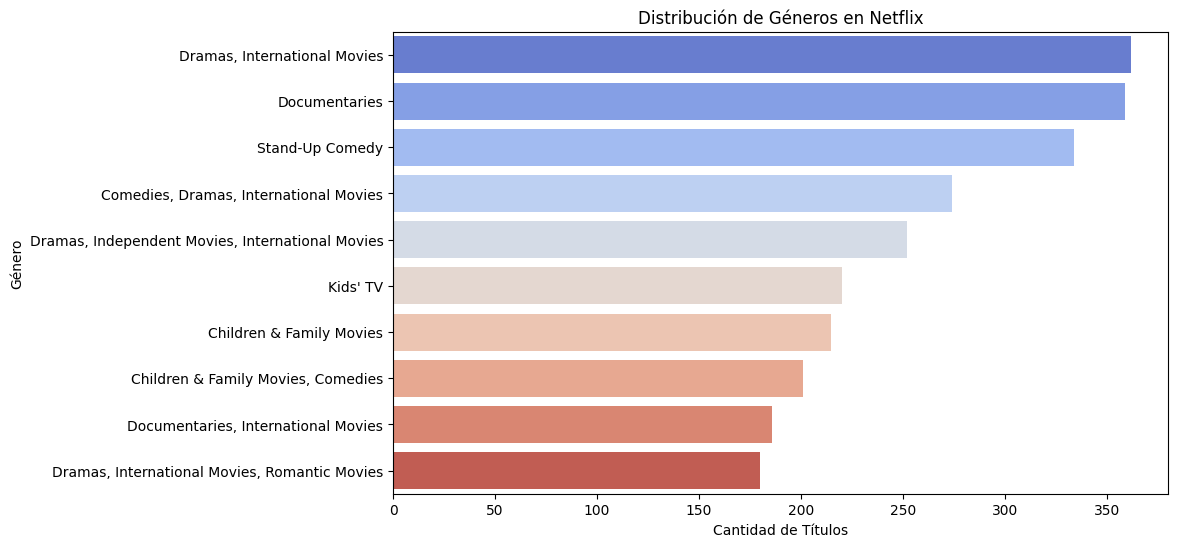

In [ ]:
# Crear un gráfico de barras de los géneros más populares
plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='coolwarm')
plt.title('Distribución de Géneros en Netflix')
plt.xlabel('Cantidad de Títulos')
plt.ylabel('Género')
plt.show()


**Gráfico 2: Evolución de lanzamientos de contenido por año**

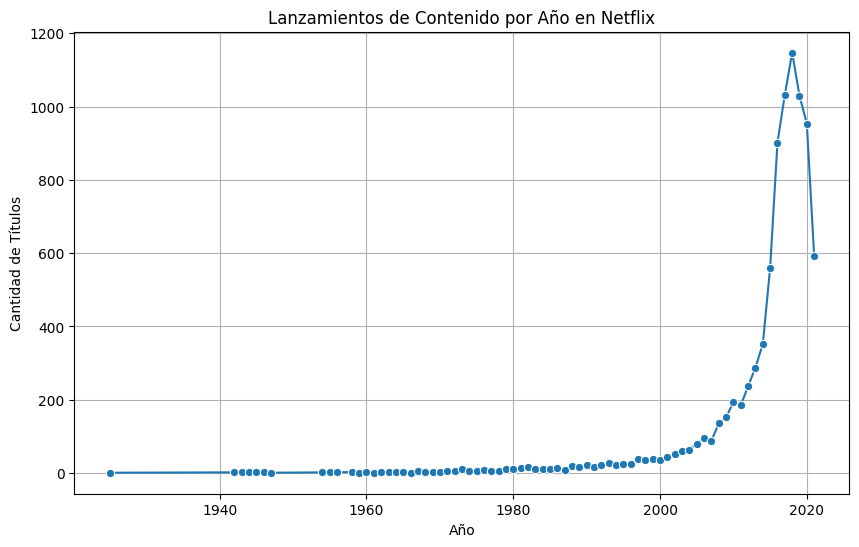

In [ ]:
# Crear un gráfico de líneas para los lanzamientos por año
plt.figure(figsize=(10,6))
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values, marker='o')
plt.title('Lanzamientos de Contenido por Año en Netflix')
plt.xlabel('Año')
plt.ylabel('Cantidad de Títulos')
plt.grid(True)
plt.show()


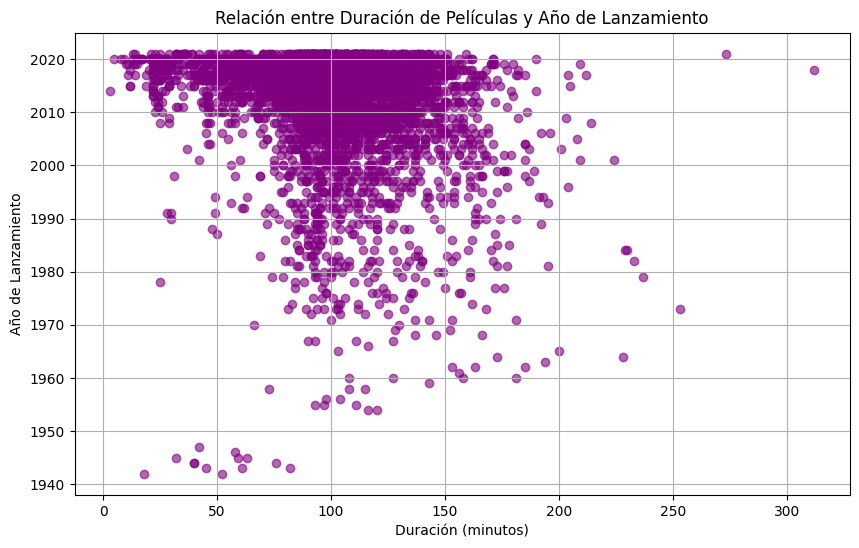

In [ ]:
# Gráfico de dispersión entre duración y año de lanzamiento
plt.figure(figsize=(10,6))
plt.scatter(df_movies['duration'], df_movies['release_year'], color='purple', alpha=0.6)
plt.title('Relación entre Duración de Películas y Año de Lanzamiento')
plt.xlabel('Duración (minutos)')
plt.ylabel('Año de Lanzamiento')
plt.grid(True)
plt.show()


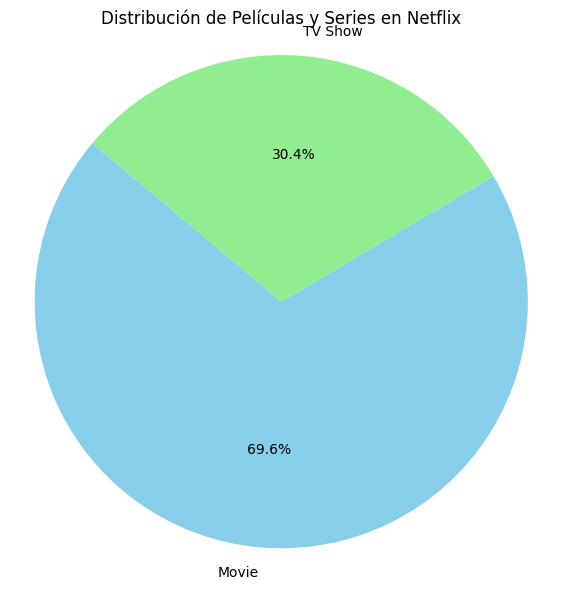

In [ ]:
# Contar la cantidad de películas y series
content_type_counts = df['type'].value_counts()

# Crear gráfico de torta
plt.figure(figsize=(7,7))
plt.pie(content_type_counts, labels=content_type_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen'])
plt.title('Distribución de Películas y Series en Netflix')
plt.axis('equal')  # Para que el gráfico sea un círculo
plt.show()


<ipython-input-19-d55f7be4f225>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='type', y='duration', data=df_movies, palette='Set2')


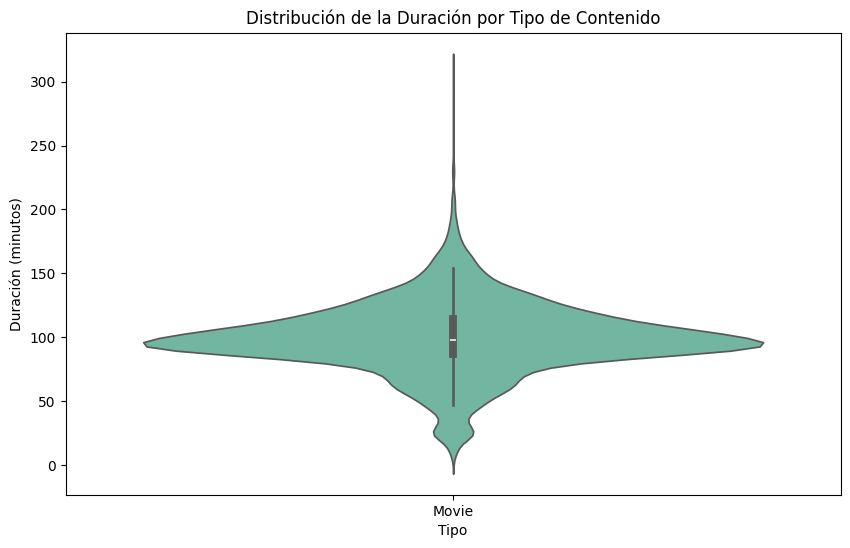

In [ ]:
# Crear gráfico de violín para la duración de las películas
plt.figure(figsize=(10,6))
sns.violinplot(x='type', y='duration', data=df_movies, palette='Set2')
plt.title('Distribución de la Duración por Tipo de Contenido')
plt.xlabel('Tipo')
plt.ylabel('Duración (minutos)')
plt.show()


**Solucion Problema con la tabla duration**

---


De string a float

In [ ]:
# Revisar los valores únicos en la columna 'duration' para identificar posibles problemas
print(df['duration'].unique())


['90 min' '2 Seasons' '1 Season' '91 min' '125 min' '9 Seasons' '104 min'
 '127 min' '4 Seasons' '67 min' '94 min' '5 Seasons' '161 min' '61 min'
 '166 min' '147 min' '103 min' '97 min' '106 min' '111 min' '3 Seasons'
 '110 min' '105 min' '96 min' '124 min' '116 min' '98 min' '23 min'
 '115 min' '122 min' '99 min' '88 min' '100 min' '6 Seasons' '102 min'
 '93 min' '95 min' '85 min' '83 min' '113 min' '13 min' '182 min' '48 min'
 '145 min' '87 min' '92 min' '80 min' '117 min' '128 min' '119 min'
 '143 min' '114 min' '118 min' '108 min' '63 min' '121 min' '142 min'
 '154 min' '120 min' '82 min' '109 min' '101 min' '86 min' '229 min'
 '76 min' '89 min' '156 min' '112 min' '107 min' '129 min' '135 min'
 '136 min' '165 min' '150 min' '133 min' '70 min' '84 min' '140 min'
 '78 min' '7 Seasons' '64 min' '59 min' '139 min' '69 min' '148 min'
 '189 min' '141 min' '130 min' '138 min' '81 min' '132 min' '10 Seasons'
 '123 min' '65 min' '68 min' '66 min' '62 min' '74 min' '131 min' '39 min'
 '46 m

In [ ]:
# Filtrar películas y series
df_movies = df[df['type'] == 'Movie']
df_series = df[df['type'] == 'TV Show']


In [ ]:
# Eliminar ' min' y convertir a float
df_movies['duration'] = df_movies['duration'].str.replace(' min', '').astype(float)


<ipython-input-24-ed5329fbc713>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration'] = df_movies['duration'].str.replace(' min', '').astype(float)


In [ ]:
# Para series, extraer el número de temporadas
df_series['duration'] = df_series['duration'].str.extract('(\d+)').astype(float)


<ipython-input-25-54cd415e4e76>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_series['duration'] = df_series['duration'].str.extract('(\d+)').astype(float)


In [ ]:
# Verificar que la columna de duración ahora contiene valores numéricos
print(df_movies['duration'].head())
print(df_series['duration'].head())


0      90.0
6      91.0
7     125.0
9     104.0
12    127.0
Name: duration, dtype: float64
1    2.0
2    1.0
3    1.0
4    2.0
5    1.0
Name: duration, dtype: float64


In [ ]:
# Eliminar filas con valores nulos en la columna 'duration'
df_movies = df_movies.dropna(subset=['duration'])

# O puedes reemplazar los valores nulos con la media de la duración
df_movies['duration'].fillna(df_movies['duration'].mean(), inplace=True)


<ipython-input-27-c356c0310e9a>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_movies['duration'].fillna(df_movies['duration'].mean(), inplace=True)
<ipython-input-27-c356c0310e9a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration'].fillna(df_movies['duration'].mean(), inplace=True)


In [ ]:
# Verificar si hay valores nulos en la columna 'duration'
missing_values = df_movies['duration'].isnull().sum()
print(f'Valores nulos en la columna duration: {missing_values}')


Valores nulos en la columna duration: 0


In [ ]:
# Verificar el tipo de datos de la columna 'duration'
print(df_movies['duration'].dtype)


float64


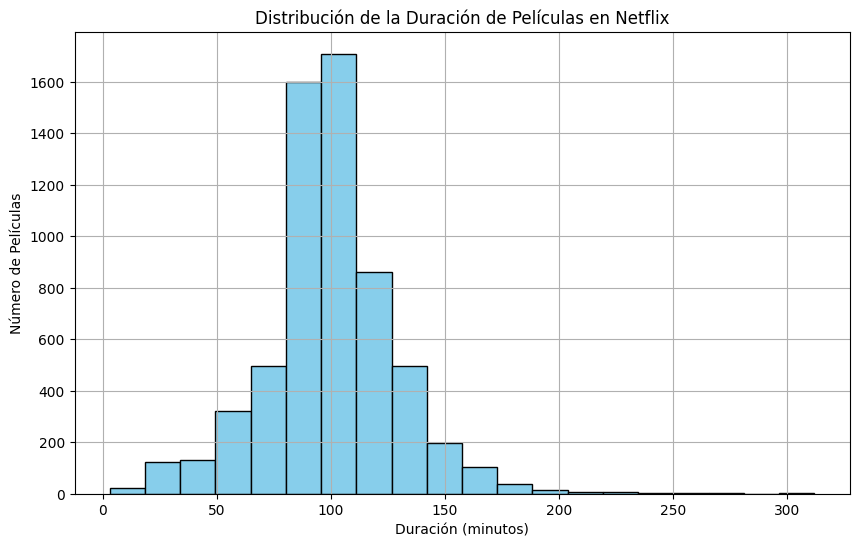

In [ ]:
# Crear un histograma para la duración de las películas
plt.figure(figsize=(10,6))
plt.hist(df_movies['duration'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de la Duración de Películas en Netflix')
plt.xlabel('Duración (minutos)')
plt.ylabel('Número de Películas')
plt.grid(True)
plt.show()
